# Assignment 1 — Python for AI Warm-Up
kLab Academy · AI Intensive · Day 1

In [45]:
import numpy, pandas, sklearn, matplotlib
print("all good")

all good


## Task 2 — Python Fundamentals

### 2.1 Five data types

In [46]:
model_name = "iris-classifier"   # str: text data, like a name or label
accuracy = 0.94                   # float: a decimal number
epochs = 10                       # int: a whole number
is_trained = True                 # bool: a yes/no flag
result = None                     # None: means "no value yet"

for value in [model_name, accuracy, epochs, is_trained, result]:
    print(value, "->", type(value))

iris-classifier -> <class 'str'>
0.94 -> <class 'float'>
10 -> <class 'int'>
True -> <class 'bool'>
None -> <class 'NoneType'>


In [47]:
raw_value = "0.87"
score = float(raw_value)        # str -> float: text becomes a real number
rounded = int(score * 100)      # float -> int: cuts off the decimal, does NOT round

print(score, type(score))
print(rounded, type(rounded))

0.87 <class 'float'>
87 <class 'int'>


In [48]:
model_name = "iris-classifier"
accuracy = 0.94
epochs = 10

print(f"{model_name} reached {accuracy:.1%} accuracy in {epochs} epochs")

iris-classifier reached 94.0% accuracy in 10 epochs


In [49]:
accuracy, threshold, latency_ms = 0.91, 0.90, 240

# decision logic: a model only "ships" if it's BOTH accurate enough AND fast enough
if accuracy >= threshold and latency_ms < 300:
    decision = "ship it"
elif accuracy >= threshold:
    decision = "accurate but too slow"
else:
    decision = "keep training"

print(decision)

ship it


In [50]:
scores = [0.71, 0.83, 0.88, 0.91]

# enumerate(scores, start=1) gives us a running epoch number alongside each score
for i, score in enumerate(scores, start=1):
    print(f"epoch {i}: {score:.2f}")

epoch 1: 0.71
epoch 2: 0.83
epoch 3: 0.88
epoch 4: 0.91


In [51]:
features = ["age", "income", "region"]      # list: ORDERED and MUTABLE - order matters, and we may add more features later
image_shape = (224, 224, 3)                   # tuple: ORDERED but IMMUTABLE - an image shape shouldn't change accidentally
config = {"model": "logreg", "C": 1.0}      # dict: KEY/VALUE - hyperparameters are named, so we look them up by name
seen_labels = {"cat", "dog", "cat"}          # set: UNIQUE VALUES ONLY - duplicates collapse automatically

print(len(features), image_shape[0], config["C"], seen_labels)

3 224 1.0 {'cat', 'dog'}


In [52]:
scores = [0.71, 0.83, 0.88, 0.91]

# list comprehension with a filter: keep only the strong scores (> 0.85)
strong = [s for s in scores if s > 0.85]

# dict comprehension: turn each score into a labelled "model_i": score entry
report = {f"model_{i}": s for i, s in enumerate(scores)}

print(strong)
print(report)

[0.88, 0.91]
{'model_0': 0.71, 'model_1': 0.83, 'model_2': 0.88, 'model_3': 0.91}


## Task 3 — Three Functions
Defined in `src/utils.py` and imported here.

In [53]:
import sys
sys.path.append("..")  # lets us import from the src/ folder one level up

from src.utils import normalise, summarise_scores, safe_divide

In [54]:
print(normalise([12, 18, 25, 40]))

# edge case: every value identical -> would divide by zero without our (hi - lo) or 1 guard
print(normalise([5, 5, 5, 5]))

[0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
[0.0, 0.0, 0.0, 0.0]


In [55]:
print(summarise_scores([0.71, 0.83, 0.88, 0.91]))

# edge case: empty list -> handled without crashing, returns zeros/None instead
print(summarise_scores([]))

{'count': 4, 'mean': 0.8325, 'minimum': 0.71, 'maximum': 0.91, 'above_threshold': 3}
{'count': 0, 'mean': None, 'minimum': None, 'maximum': None, 'above_threshold': 0}


In [56]:
print(safe_divide(10, 2))        # normal case
print(safe_divide(10, 0))        # divide-by-zero case -> falls back to default
print(safe_divide(10, "oops"))   # text-input case -> falls back to default

5.0
0.0
0.0


## Task 4 — NumPy and Pandas
### 4.1 NumPy: 1-D array

In [57]:
import numpy as np

scores = np.array([0.71, 0.83, 0.88, 0.91, 0.65, 0.77])  # at least 6 numbers
print("mean:", scores.mean())
print("std:", scores.std())
print("min:", scores.min())
print("max:", scores.max())

mean: 0.7916666666666666
std: 0.09172725270544675
min: 0.65
max: 0.91


In [58]:
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
])
print("shape:", matrix.shape)              # (3, 4)
print("transpose shape:", matrix.T.shape)  # (4, 3) - rows and columns swap

shape: (3, 4)
transpose shape: (4, 3)


In [59]:
column_means = matrix.mean(axis=0)  # mean() down each column
centered = matrix - column_means    # broadcasting: NumPy repeats column_means across every row automatically
print("column means:", column_means)
print(centered)

column means: [5. 6. 7. 8.]
[[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


### 4.2 Pandas: build a DataFrame

In [60]:
import pandas as pd

df = pd.DataFrame({
    "candidate": ["Aline", "Bosco", "Chantal", "David", "Eric", "Fiona"],
    "experience": [1, 4, 3, None, 2, 5],       # missing value on purpose (David)
    "score": [0.62, 0.91, 0.78, 0.55, 0.83, 0.95],
    "region": ["Kigali", "Huye", "Kigali", "Musanze", "Huye", "Kigali"],  # text column
})
df

,candidate,experience,score,region
0,Aline,1.0,0.62,Kigali
1,Bosco,4.0,0.91,Huye
2,Chantal,3.0,0.78,Kigali
3,David,NaN,0.55,Musanze
4,Eric,2.0,0.83,Huye
5,Fiona,5.0,0.95,Kigali


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   candidate   6 non-null      str    
 1   experience  5 non-null      float64
 2   score       6 non-null      float64
 3   region      6 non-null      str    
dtypes: float64(2), str(2)
memory usage: 324.0 bytes


In [62]:
df.describe()

,experience,score
count,5.000000,6.000000
mean,3.000000,0.773333
std,1.581139,0.159081
min,1.000000,0.550000
25%,2.000000,0.660000
50%,3.000000,0.805000
75%,4.000000,0.890000
max,5.000000,0.950000


In [63]:
df.isna().sum()

candidate     0
experience    1
score         0
region        0
dtype: int64

**On the missing value:** if this were real data, the missing `experience` value for
David would mean we don't actually know his work history , we can't assume it's zero,
since that would understate his experience and unfairly bias any model trained on this
column. Before using this data for anything serious, we'd need to find out *why* it's
missing rather than silently filling it in.

In [64]:
strong_candidates = df[df["score"] > 0.7].sort_values("score", ascending=False)
strong_candidates

,candidate,experience,score,region
5,Fiona,5.0,0.95,Kigali
1,Bosco,4.0,0.91,Huye
4,Eric,2.0,0.83,Huye
2,Chantal,3.0,0.78,Kigali


In [65]:
df["pass"] = df["score"] >= 0.7  # boolean pass/fail flag derived from the score column
df

,candidate,experience,score,region,pass
0,Aline,1.0,0.62,Kigali,False
1,Bosco,4.0,0.91,Huye,True
2,Chantal,3.0,0.78,Kigali,True
3,David,NaN,0.55,Musanze,False
4,Eric,2.0,0.83,Huye,True
5,Fiona,5.0,0.95,Kigali,True


## Task 5 — One Chart, One Claim

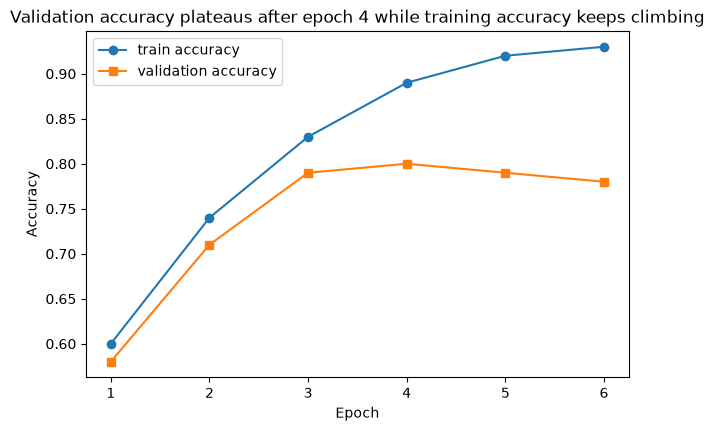

In [66]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5, 6]
train_acc = [0.60, 0.74, 0.83, 0.89, 0.92, 0.93]
val_acc   = [0.58, 0.71, 0.79, 0.80, 0.79, 0.78]

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, train_acc, marker="o", label="train accuracy")
plt.plot(epochs, val_acc, marker="s", label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation accuracy plateaus after epoch 4 while training accuracy keeps climbing")
plt.legend()
plt.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Done
Every task from the Day 1 assignment brief is demonstrated above with printed, verified output.